In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os
import sys

In [8]:
# Load the raw npz file
raw_data = np.load('linear_simulation_data.npz')
y_vals = raw_data['y_vals']
u_plot = raw_data['u_plot']

# Assuming y_vals contains [Cart 1 Pos, Cart 1 Vel, Cart 2 Pos, Cart 2 Vel]
columns = ['Input Force (u)', 'Cart 1 Pos (x1)', 'Cart 1 Vel (x1_dot)', 'Cart 2 Pos (x2)', 'Cart 2 Vel (x2_dot)']

# Create a DataFrame combining both raw arrays
# We use np.column_stack to attach the 1D u_plot alongside the 2D y_vals
df = pd.DataFrame(
    np.column_stack((u_plot, y_vals)),
    columns=columns
)

# Set the index name to represent Time Steps
df.index.name = 'Time Step'
display(df.head(10))


,Input Force (u),Cart 1 Pos (x1),Cart 1 Vel (x1_dot),Cart 2 Pos (x2),Cart 2 Vel (x2_dot)
Time Step,,,,,
0,1.490142,0.000000,0.000000,0.000000e+00,0.000000
1,1.490142,0.000296,0.058910,9.913587e-07,0.000297
2,1.490142,0.001174,0.116426,7.913124e-06,0.001185
3,1.490142,0.002620,0.172548,2.664549e-05,0.002658
4,1.490142,0.004620,0.227274,6.300974e-05,0.004710
5,1.490142,0.007160,0.280606,1.227639e-04,0.007335
6,1.490142,0.010227,0.332545,2.115986e-04,0.010525
7,1.490142,0.013807,0.383094,3.351329e-04,0.014274
8,1.490142,0.017885,0.432258,4.989105e-04,0.018573


In [9]:
# normalize the data 
y_mean, y_std = y_vals.mean(axis=0), y_vals.std(axis=0)
u_mean, u_std = u_plot.mean(), u_plot.std()

y_norm = (y_vals - y_mean) / (y_std + 1e-8)
u_norm = (u_plot - u_mean) / (u_std + 1e-8)

# convert to torch tensors
Y = torch.tensor(y_norm, dtype=torch.float32)
U = torch.tensor(u_norm, dtype=torch.float32).unsqueeze(1)

print(f"Data is normalized. Final shapes ready for model:")
print(f"Y Shape: {Y.shape} | U Shape: {U.shape}")

Data is normalized. Final shapes ready for model:
Y Shape: torch.Size([20000, 4]) | U Shape: torch.Size([20000, 1])


In [10]:
# define the model
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        
        # Memory Update Weights
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.1)
        self.W_uh = nn.Parameter(torch.randn(input_size, hidden_size) * 0.1)
        self.b_h = nn.Parameter(torch.zeros(hidden_size))
        
        # State Prediction Weights
        self.W_hx = nn.Parameter(torch.randn(hidden_size, output_size) * 0.1)
        self.b_x = nn.Parameter(torch.zeros(output_size))
    
    def forward(self, combined_u_seq):
        # get sequence length
        seq_len = combined_u_seq.shape[0]

        # initialize hidden state
        h_k = torch.zeros(self.hidden_size, device=combined_u_seq.device)

        # initialize list to store predictions
        y_pred = []

        # loop through the sequence
        for k in range(seq_len):
            # contains [x1, v1, x2, v2, force]
            step_data = combined_u_seq[k]

            # update hidden state
            h_k = torch.relu(h_k @ self.W_hh + step_data @ self.W_uh + self.b_h)

            # predict next state
            y_k = h_k @ self.W_hx + self.b_x

            # store prediction
            y_pred.append(y_k)

        # convert list to tensor
        y_pred = torch.stack(y_pred)

        return y_pred

# Training with `hidden_size=8` and `seq_len=100`. Also lowered learning rate to 0.0001 and applied gradient clipping

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# train the model
model = RNN(input_size=5, hidden_size=8, output_size=4).to(device) # changed this to 5 (4 current states + 1 input force)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# training loop
n_epochs = 600
seq_len = 100

loss_history = []

batch_size = 16

for epoch in range(n_epochs):
    # zero the gradients
    optimizer.zero_grad()
    
    batch_loss = 0

    for _ in range(batch_size):
        # Pick a random starting point in the sequence
        start_idx = np.random.randint(0, len(U) - seq_len - 1) # -1 cuz we need more space to get the traget one step in the future
        end_idx = start_idx + seq_len
        
        # Get current states and inputs
        U_curr = U[start_idx:end_idx].to(device)
        Y_curr = Y[start_idx:end_idx].to(device)
        
        # combine current state and input 
        combined_input = torch.cat((Y_curr, U_curr), dim=1)

        # NEW: get next states (target shifted by +1)
        Y_target = Y[start_idx + 1: end_idx + 1].to(device)

        # forward pass
        Y_pred_chunk = model(combined_input)
        
        # calculate loss
        loss = criterion(Y_pred_chunk, Y_target)
        loss = loss/batch_size
        
        # backpropagate and update
        loss.backward()
        batch_loss += (loss.item() * batch_size)
        
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    loss_history.append(loss.item())
    
    # print the loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Average Batch Loss: {batch_loss / batch_size:.4f}")

Training on: cuda
Epoch 10/600, Average Batch Loss: 1.2076
Epoch 20/600, Average Batch Loss: 1.2017
Epoch 30/600, Average Batch Loss: 0.9279
Epoch 40/600, Average Batch Loss: 1.2754
Epoch 50/600, Average Batch Loss: 1.1028
Epoch 60/600, Average Batch Loss: 1.3083
Epoch 70/600, Average Batch Loss: 0.9120
Epoch 80/600, Average Batch Loss: 1.3657
Epoch 90/600, Average Batch Loss: 0.9344
Epoch 100/600, Average Batch Loss: 0.4719
Epoch 110/600, Average Batch Loss: 0.8879
Epoch 120/600, Average Batch Loss: 0.7224
Epoch 130/600, Average Batch Loss: 0.8141
Epoch 140/600, Average Batch Loss: 0.9351
Epoch 150/600, Average Batch Loss: 0.9941
Epoch 160/600, Average Batch Loss: 0.9544
Epoch 170/600, Average Batch Loss: 0.9030
Epoch 180/600, Average Batch Loss: 1.1398
Epoch 190/600, Average Batch Loss: 1.1000
Epoch 200/600, Average Batch Loss: 1.0598
Epoch 210/600, Average Batch Loss: 0.5561
Epoch 220/600, Average Batch Loss: 0.4189
Epoch 230/600, Average Batch Loss: 0.5711
Epoch 240/600, Average Ba

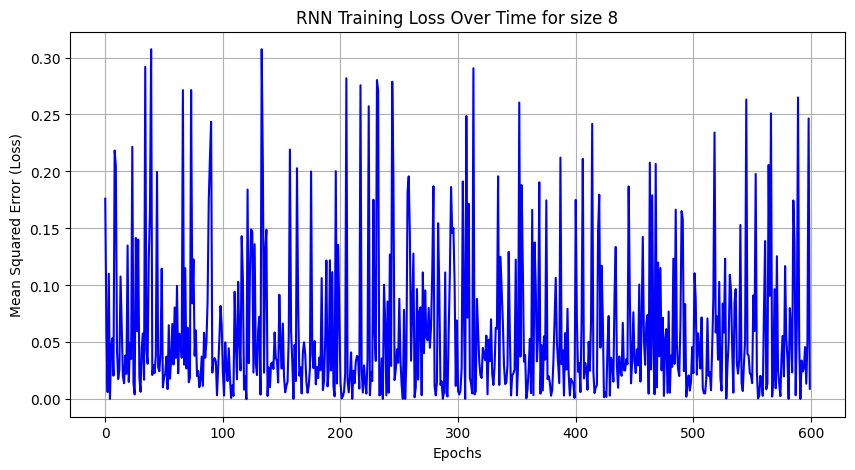

In [13]:
# Plot the Learning Curve
plt.figure(figsize=(10, 5))

# Plot the saved list
plt.plot(loss_history, color='blue')
plt.title('RNN Training Loss Over Time for size 8')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.grid(True)
plt.show()


Evaluating trained RNN in Closed-Loop Autoregressive for Size 8


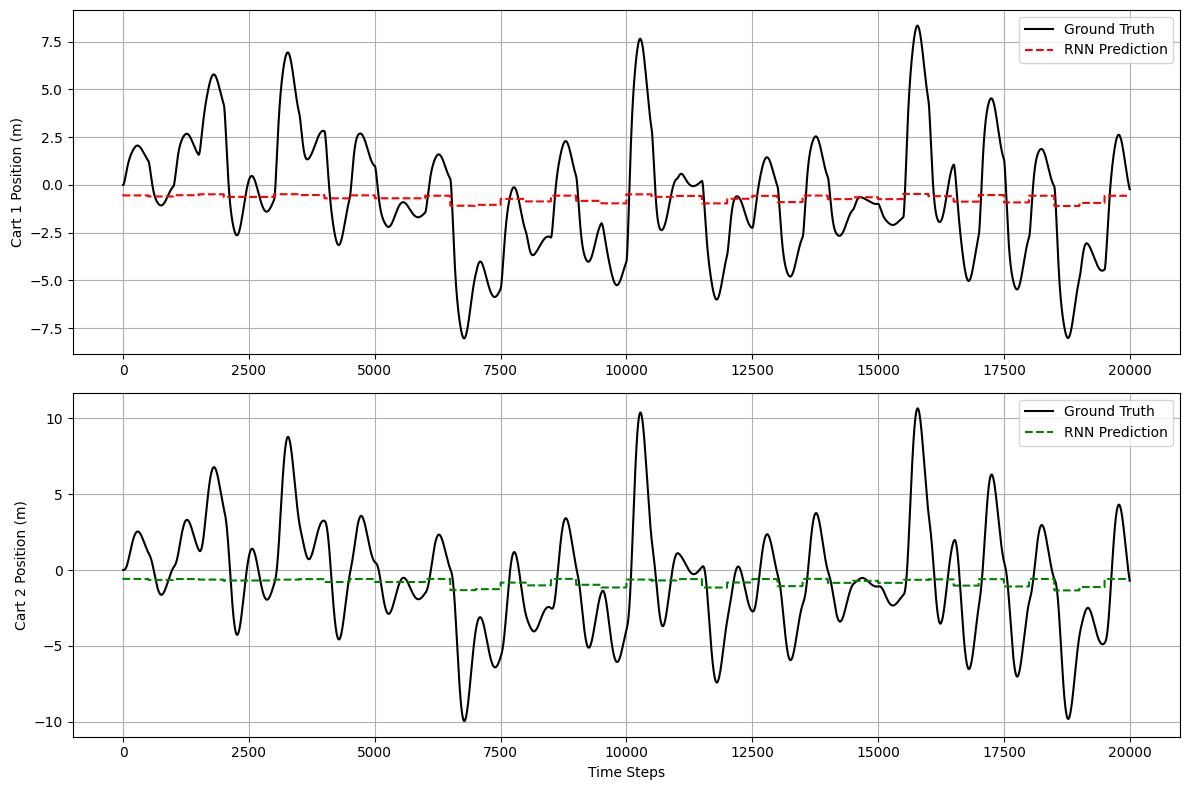

In [15]:
# evaluate the model
print("Evaluating trained RNN in Closed-Loop Autoregressive for Size 8")
model.eval()

with torch.no_grad():
    continous_pred = []
    current_state = Y[0].to(device)

    # init hidden memory for all 20,000 steps
    h_k = torch.zeros(model.hidden_size, device=device)

    for k in range(len(U)):
        # get true input for this time step
        u_k = U[k].to(device)

        # combine current input with current force
        step_data = torch.cat((current_state, u_k))

        # forward pass this time step
        h_k = torch.relu(h_k @ model.W_hh + step_data @ model.W_uh + model.b_h)
        next_state_pred = h_k @ model.W_hx + model.b_x

        # save this prediction
        continous_pred.append(next_state_pred)

        # feedback loop
        current_state = next_state_pred

    Y_pred_norm = torch.stack(continous_pred)
    # Convert to numpy and un-normalize
    Y_pred = Y_pred_norm.cpu().numpy() * y_std + y_mean

# Plotting Results
plt.figure(figsize=(12, 8))

# Plot Cart 1 Position (x1)
plt.subplot(2, 1, 1)
plt.plot(y_vals[:, 0], 'k-', label='Ground Truth')
plt.plot(Y_pred[:, 0], 'r--', label='RNN Prediction')
plt.ylabel('Cart 1 Position (m)')
plt.legend()
plt.grid(True)

# Plot Cart 2 Position (x2)
plt.subplot(2, 1, 2)
plt.plot(y_vals[:, 2], 'k-', label='Ground Truth')
plt.plot(Y_pred[:, 2], 'g--', label='RNN Prediction')
plt.ylabel('Cart 2 Position (m)')
plt.xlabel('Time Steps')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Training with `hidden_size=64` and `seq_len=100`. Also lowered learning rate to 0.0001 and applied gradient clipping

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# train the model
model = RNN(input_size=5, hidden_size=64, output_size=4).to(device) # changed this to 5 (4 current states + 1 input force)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# training loop
n_epochs = 1000
seq_len = 100

loss_history = []

batch_size = 16

for epoch in range(n_epochs):
    # zero the gradients
    optimizer.zero_grad()
    
    batch_loss = 0

    for _ in range(batch_size):
        # Pick a random starting point in the sequence
        start_idx = np.random.randint(0, len(U) - seq_len - 1) # -1 cuz we need more space to get the traget one step in the future
        end_idx = start_idx + seq_len
        
        # Get current states and inputs
        U_curr = U[start_idx:end_idx].to(device)
        Y_curr = Y[start_idx:end_idx].to(device)
        
        # combine current state and input 
        combined_input = torch.cat((Y_curr, U_curr), dim=1)

        # NEW: get next states (target shifted by +1)
        Y_target = Y[start_idx + 1: end_idx + 1].to(device)

        # forward pass
        Y_pred_chunk = model(combined_input)
        
        # calculate loss
        loss = criterion(Y_pred_chunk, Y_target)
        loss = loss/batch_size
        
        # backpropagate and update
        loss.backward()
        batch_loss += (loss.item() * batch_size)
        
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    loss_history.append(loss.item())
    
    # print the loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Average Batch Loss: {batch_loss / batch_size:.4f}")

Training on: cuda
Epoch 10/1000, Average Batch Loss: 0.7884
Epoch 20/1000, Average Batch Loss: 0.5728
Epoch 30/1000, Average Batch Loss: 0.8679
Epoch 40/1000, Average Batch Loss: 0.7734
Epoch 50/1000, Average Batch Loss: 0.5948
Epoch 60/1000, Average Batch Loss: 0.9741
Epoch 70/1000, Average Batch Loss: 0.9772
Epoch 80/1000, Average Batch Loss: 0.5250
Epoch 90/1000, Average Batch Loss: 0.4214
Epoch 100/1000, Average Batch Loss: 0.6465
Epoch 110/1000, Average Batch Loss: 0.7157
Epoch 120/1000, Average Batch Loss: 0.6985
Epoch 130/1000, Average Batch Loss: 0.3183
Epoch 140/1000, Average Batch Loss: 0.4196
Epoch 150/1000, Average Batch Loss: 0.6494
Epoch 160/1000, Average Batch Loss: 0.3400
Epoch 170/1000, Average Batch Loss: 0.8506
Epoch 180/1000, Average Batch Loss: 0.5413
Epoch 190/1000, Average Batch Loss: 0.5263
Epoch 200/1000, Average Batch Loss: 0.5437
Epoch 210/1000, Average Batch Loss: 0.3685
Epoch 220/1000, Average Batch Loss: 0.2334
Epoch 230/1000, Average Batch Loss: 0.1178
Ep

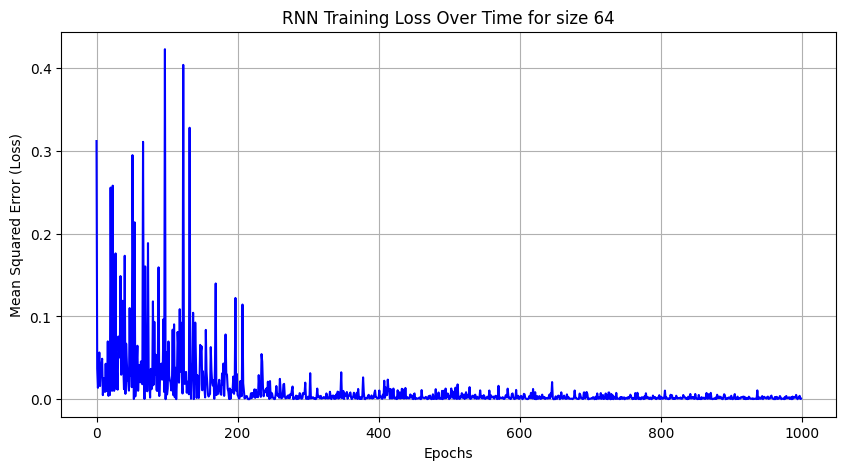

In [21]:
# Plot the Learning Curve
plt.figure(figsize=(10, 5))

# Plot the saved list
plt.plot(loss_history, color='blue')
plt.title('RNN Training Loss Over Time for size 64')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.grid(True)
plt.show()


Evaluating trained RNN in Closed-Loop Autoregressive for Size 64


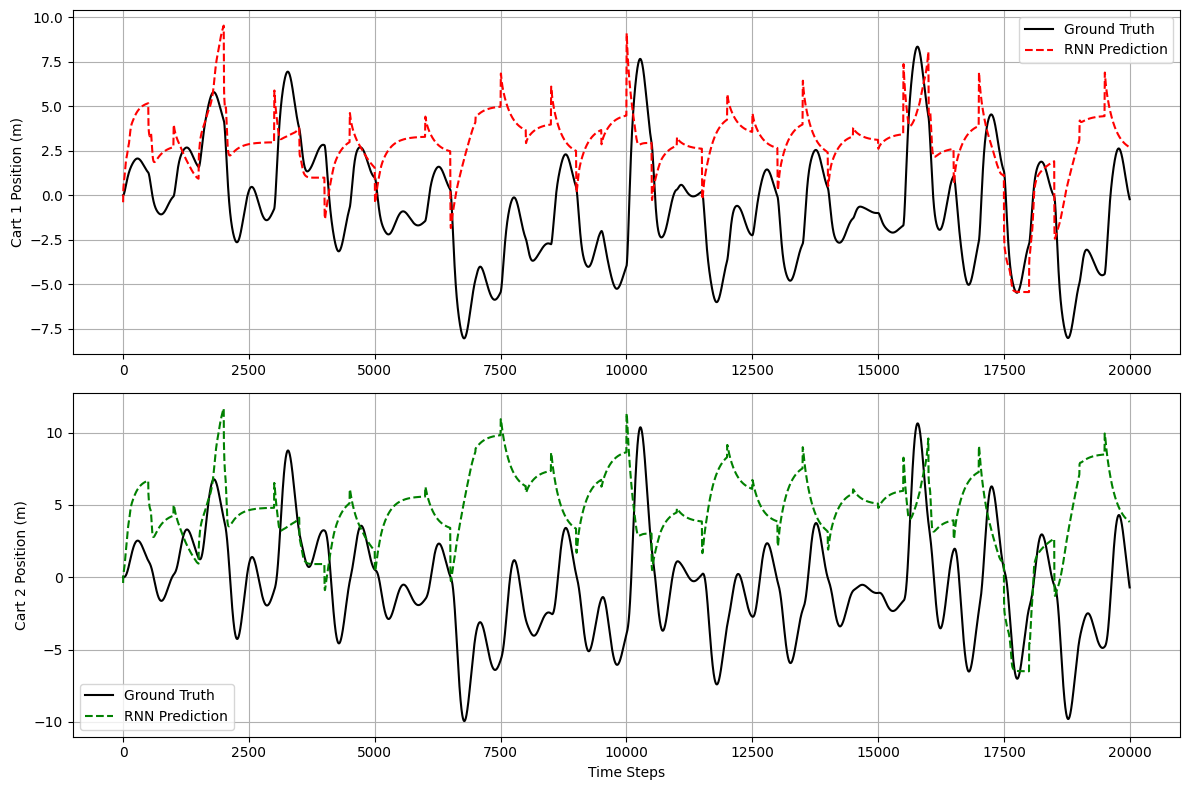

In [22]:
# evaluate the model
print("Evaluating trained RNN in Closed-Loop Autoregressive for Size 64")
model.eval()

with torch.no_grad():
    continous_pred = []
    current_state = Y[0].to(device)

    # init hidden memory for all 20,000 steps
    h_k = torch.zeros(model.hidden_size, device=device)

    for k in range(len(U)):
        # get true input for this time step
        u_k = U[k].to(device)

        # combine current input with current force
        step_data = torch.cat((current_state, u_k))

        # forward pass this time step
        h_k = torch.relu(h_k @ model.W_hh + step_data @ model.W_uh + model.b_h)
        next_state_pred = h_k @ model.W_hx + model.b_x

        # save this prediction
        continous_pred.append(next_state_pred)

        # feedback loop
        current_state = next_state_pred

    Y_pred_norm = torch.stack(continous_pred)
    # Convert to numpy and un-normalize
    Y_pred = Y_pred_norm.cpu().numpy() * y_std + y_mean

# Plotting Results
plt.figure(figsize=(12, 8))

# Plot Cart 1 Position (x1)
plt.subplot(2, 1, 1)
plt.plot(y_vals[:, 0], 'k-', label='Ground Truth')
plt.plot(Y_pred[:, 0], 'r--', label='RNN Prediction')
plt.ylabel('Cart 1 Position (m)')
plt.legend()
plt.grid(True)

# Plot Cart 2 Position (x2)
plt.subplot(2, 1, 2)
plt.plot(y_vals[:, 2], 'k-', label='Ground Truth')
plt.plot(Y_pred[:, 2], 'g--', label='RNN Prediction')
plt.ylabel('Cart 2 Position (m)')
plt.xlabel('Time Steps')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()